Ceci est une pré-analyse rapide des données. uniquement de l'exploration et du prédictif. on joindra nos analyse pour voir de quel coté on va ensemble finalement.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")

SEED = 42

Chargement des données 

In [2]:
df = pd.read_csv("../../../data/regularite-mensuelle-tgv-aqst.csv",sep=";")

on a quoi dedans ??

In [3]:
df.describe()

,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
count,12544.000000,12544.000000,12544.000000,0.0,12544.000000,12544.000000,12544.000000,0.0,12544.000000,12544.000000,...,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000
mean,170.628508,272.623884,8.407685,NaN,86.219866,12.499854,3.175135,NaN,38.243304,35.471909,...,27.576531,36.739460,13.025989,5.370615,21.897002,21.491158,20.118126,18.993447,7.762730,7.581653
std,87.730733,183.559230,22.089205,NaN,88.428503,11.660090,5.054562,NaN,31.826539,15.605191,...,23.316212,19.388035,12.684545,6.250032,16.068989,14.914196,14.709970,13.564449,8.682545,9.451102
min,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,-229.269444,NaN,0.000000,-40.109259,...,0.000000,-4.000000,-44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.000000,151.000000,0.000000,NaN,22.000000,6.346596,1.226076,NaN,16.000000,25.958062,...,11.000000,28.732917,4.000000,1.000000,10.714286,11.538462,10.000000,10.000000,0.000000,0.000000
50%,163.000000,230.000000,2.000000,NaN,52.000000,10.560933,2.368000,NaN,30.000000,33.777423,...,22.000000,38.004578,10.000000,3.000000,19.642857,20.000000,18.461538,17.142857,5.882353,5.031800
75%,223.000000,362.000000,7.000000,NaN,126.000000,16.101225,4.031985,NaN,52.000000,42.776681,...,37.000000,47.501389,18.000000,7.000000,30.252101,29.268293,28.571429,25.617573,11.398558,11.111111
max,786.000000,1100.000000,297.000000,NaN,596.000000,316.188095,115.047390,NaN,376.000000,299.600000,...,312.000000,299.600000,202.000000,77.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [4]:
df.shape

(12544, 26)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         12544 non-null  str    
 1   Service                                                                                      12544 non-null  str    
 2   Gare de départ                                                                               12544 non-null  str    
 3   Gare d'arrivée                                                                               12544 non-null  str    
 4   Durée moyenne du trajet                                                                      12544 non-null  int64  
 5   Nombre de circulations prévues             

In [6]:
df.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,32,5.363539,9,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386


Sur un premier coup d'oeil, on peut voir : 

1) Ce sont des statistiques de régularité mensuelles pour diverses lignes 

2) certaines colonnes doivent être retypée car 
- float64 mais ne l'étant pas. ex : "commentaire annulations" au lieu de str
- str qui doivent devenir category. ex : Service (nationnal / internationnal / ...)
- Date est une str, il faut la mettre en date

3) on peut déjà voir qu'il y a des données étranges :
- divers retard moyen, ou nombre de train : le min est négatif parfois fortement => à nettoyer proprement (impact ?)
- des NaN sur des commentaires (a priori on ne gardera pas les colonnes de commentaires)


Apres réunion ce vendredi : on explore plusieures pistes car il faut avoir du contenu à présenter et c'est plutot la le problème : trouver des sujets en analysant les données. je pense me concentrer sur la partie "voyage sans soucis" ou comment prévoir les retards éventuels avant de prendre son train et proposer des dates différentes pour corriger.
Il me vient ces idées en tête : 
- voir si on peut inférer l'affluence des voyageur dans le futur (on peut s'attendre a retrouver des dates de vacances)
- voir si on peut inférer les lignes 
- y a-t-il un lien entre affluence et les diverses colonnes de retard ?
- y a-t-il un lien entre la data et chacun des différents problèmes rencontré ? et sur le retard ?
- peut-on dresser des saisons ? si oui on transforme la date en pseudo temperature et on peu essayer de voir d'autres lien avec.
- peut-on utiliser une régression linéaire sur les données (affluence, saison) pour permettre de prévoir les retard ?
Si je commence à répondre a ses questions, on pourrait voir si :
- prédire une probabilité de retard pour la ligne et la date saisie par l'utilisateur, et un écart type / stats compréhensibles pour l'utilisateur 
- on peut dresser un carte de prévision de retards
- donner des contre mesure pour améliorer son trajet : changement de date ou d'horaire (nos stats sont pas mois donc c'est un suggestion)

Je part sur cet aspect mais on peut aussi voir les bénéfice pour un cheminot qui veut comprendre comment améliorer les choses (à voir plus tard).

On garde toutes les colonnes sauf nationnalité et commentaires. 


Il y a la zone covid qui semble être intéressante : éventuellement a supprimer dans certains cas, ou à conserver dans d'autres ...


In [ ]:
# micro nettoyage des données

df_clean = df.drop(columns=["Service", "Commentaire annulations", "Commentaire retards au départ", "Commentaire retards à l'arrivée"])
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean["Gare de départ"] = df_clean["Gare de départ"].astype("category")
df_clean["Gare d'arrivée"] = df_clean["Gare d'arrivée"].astype("category")



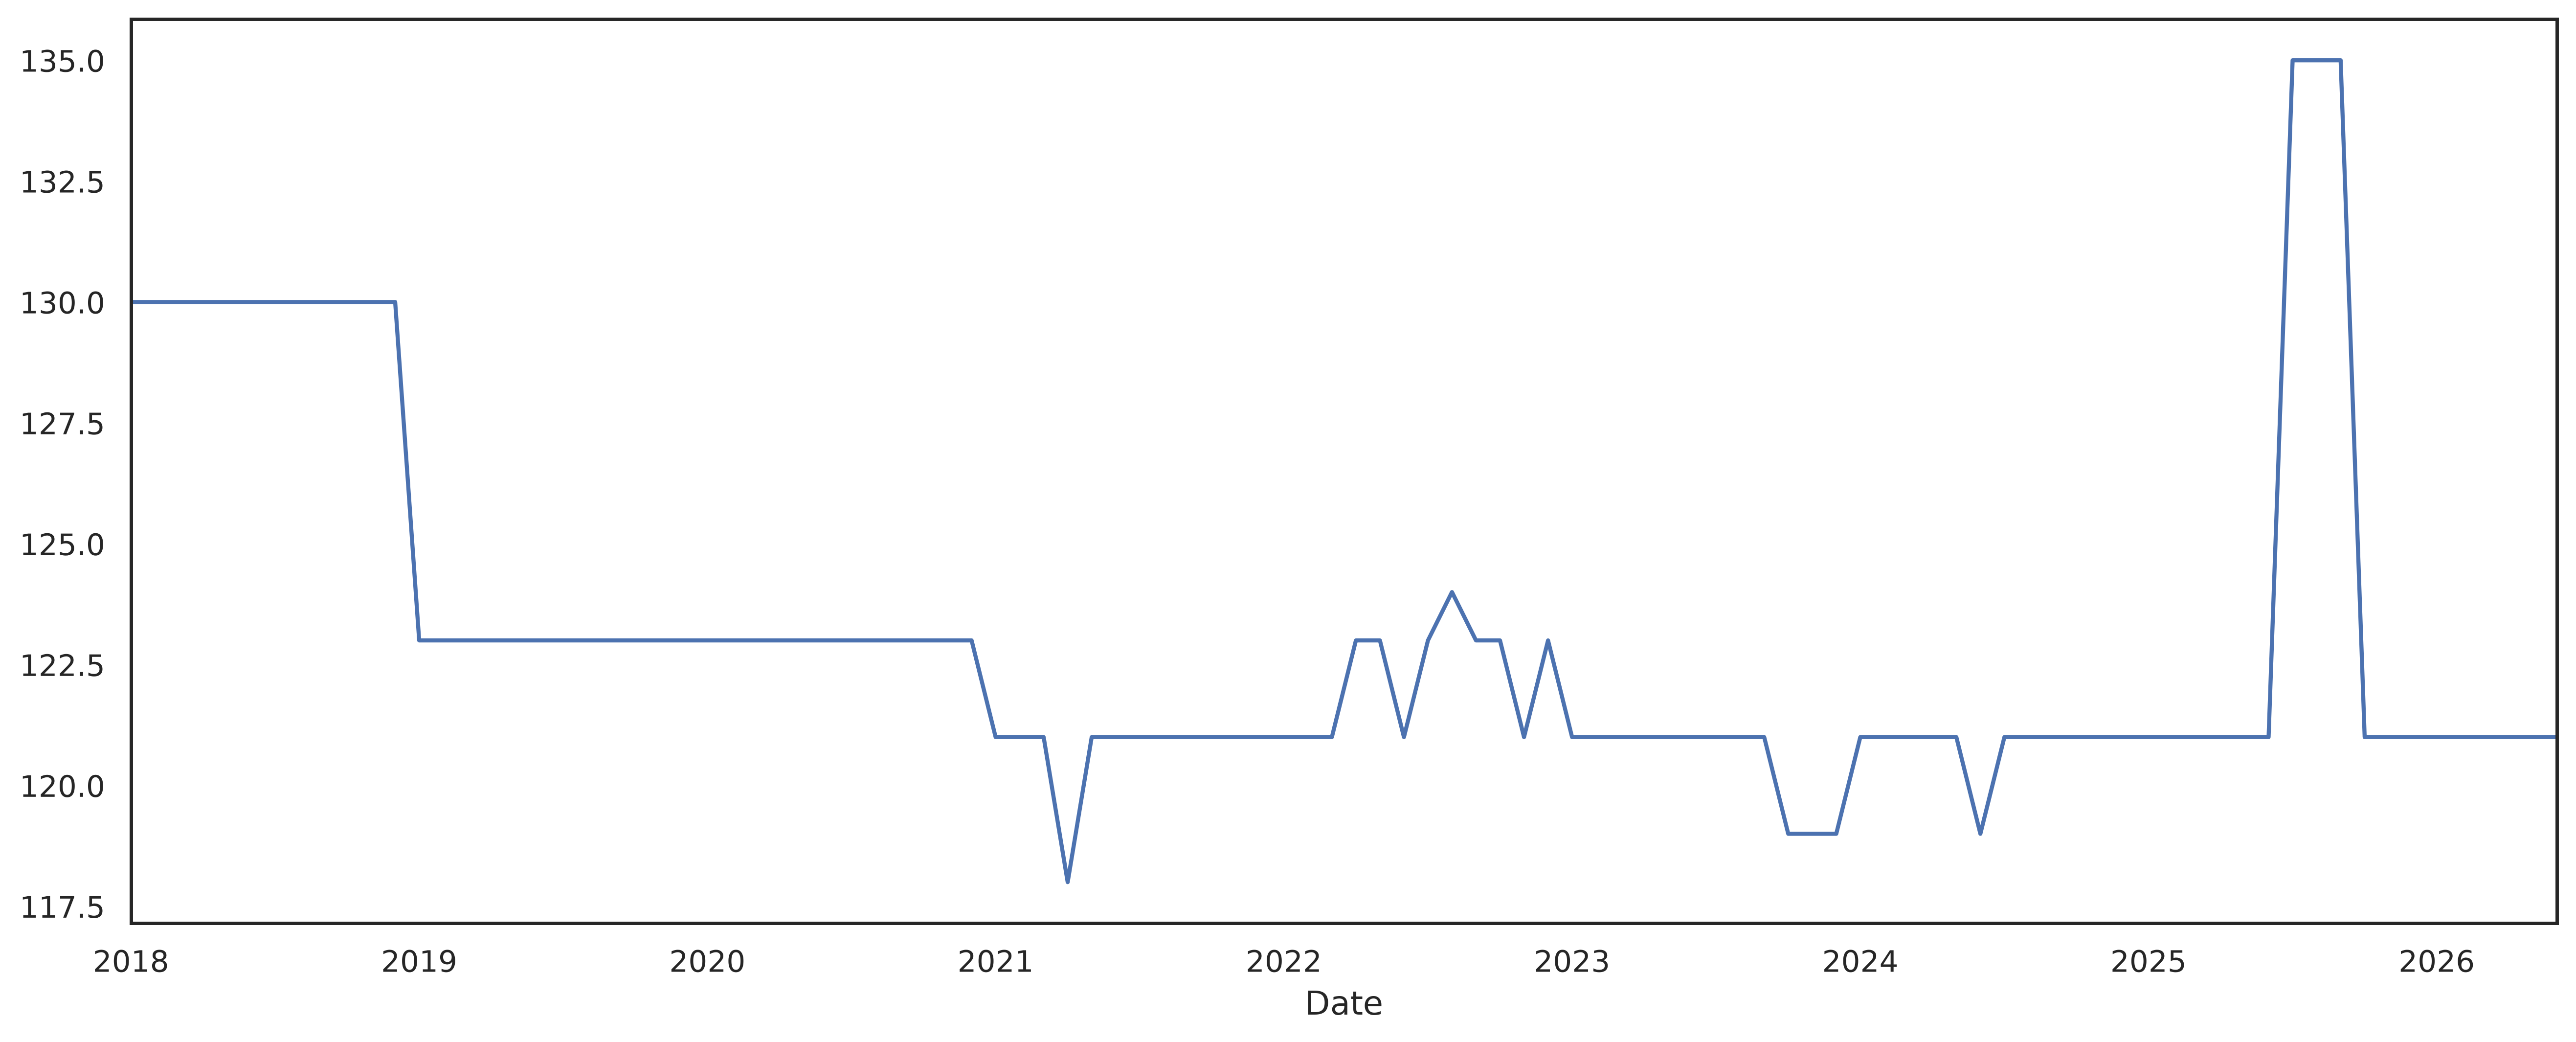

In [8]:
# on a quelques variations du nombre de ligne par date. donc je pense que les données générales ne sont pas au top.
count = df_clean.groupby("Date").size()

fig = plt.figure(figsize=(16,6))
fig.set_dpi(400)

count.plot(kind="line")
plt.show()

D'ou viennent ces changements ? 

- le pic été 2025 : c'est les JO de Paris => c'est bon !
- période covid : mars 2020 / mars 2022 : pas trop visible ...
- grande grève SNCF avril 2018 / juin 2018 : 2 jours sur 5. je ne sais pas s'ils ont prévus plus de train pour compenser suite à des annulations au dernier moment : TODO A VERIFIER mais potentiellement les lignes prévues sont gardée et ils en ajoute pour gérer les problème
- il faut savoir que la SNCF "neutralise" les retards les jours de grève pour ne pas dégrader leurs stats. on a très probablement des données neutralisées et donc il faut se méfier des données dans ces zones la de toutes les manières : a moins de les exploiter pour en tirer profit !


            Date      Gare de départ      Gare d'arrivée  \
7391  2022-12-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
7531  2023-01-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
7750  2023-03-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
8112  2023-06-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
8403  2023-09-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
8523  2023-10-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
8538  2023-10-01  PARIS MONTPARNASSE    BORDEAUX ST JEAN   
8857  2023-12-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
8867  2023-12-01  PARIS MONTPARNASSE    BORDEAUX ST JEAN   
8880  2024-01-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
8968  2024-01-01  PARIS MONTPARNASSE    BORDEAUX ST JEAN   
9203  2024-03-01  PARIS MONTPARNASSE    BORDEAUX ST JEAN   
9224  2024-03-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
9327  2024-04-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
9384  2024-05-01    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
9542  2024-06-01    BORDEAUX ST JEAN  PA

<Axes: title={'center': 'nombre de circulations prévues par mois - BORDEAUX ST JEAN -> PARIS MONTPARNASSE'}, xlabel='Mois'>

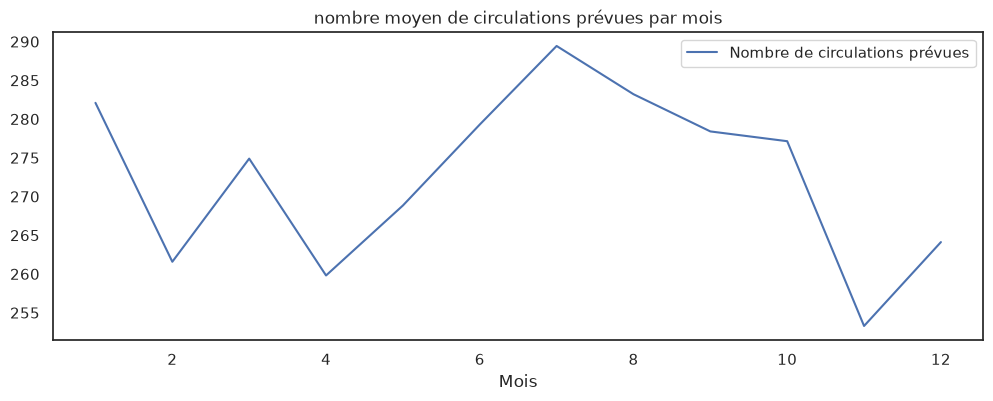

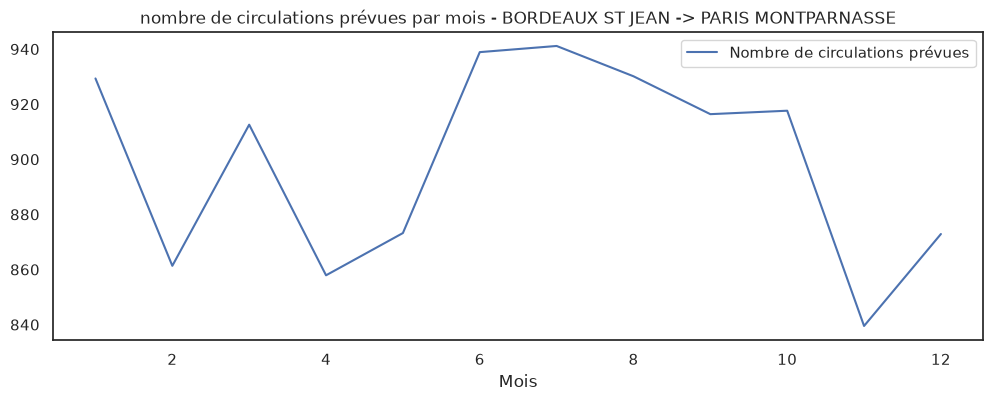

In [38]:
# affluence des trains par mois : Nombre de circulations prévues
# on a pas mal de valeurs hors norme. pourquoi ?

colonne = "Nombre de circulations prévues"

df_analyse = df_clean.copy()
df_analyse["Mois"] = df_analyse["Date"].dt.month
df_analyse["Mois"] = df_analyse["Mois"].astype("int8")

#df_analyse.boxplot(column=colonne)   # on voit des valeurs extrêmes.
#df_analyse[colonne].hist(bins=120)    # la répartition montre un groupe distinct aux alentours des 1000
print(df_analyse[df_analyse[colonne] > 1050])  # toujours l'axe BORDEAU ST JEAN <-> PARIS MONTPARNASSE
# en fin de compte, c'est peut être normal ...

df_analyse_mois = df_analyse.groupby(["Mois"]).agg({colonne: "mean"}).reset_index()
df_analyse_mois.plot(x="Mois", y=colonne, kind="line", figsize=(12,4), title="nombre moyen de circulations prévues par mois")

df_analyse = df_analyse.query("`Gare de départ` == 'BORDEAUX ST JEAN' and `Gare d'arrivée` == 'PARIS MONTPARNASSE'")
df_analyse_mois = df_analyse.groupby(["Mois"]).agg({colonne: "mean"}).reset_index()
df_analyse_mois.plot(x="Mois", y=colonne, kind="line", figsize=(12,4), title="nombre de circulations prévues par mois - BORDEAUX ST JEAN -> PARIS MONTPARNASSE")


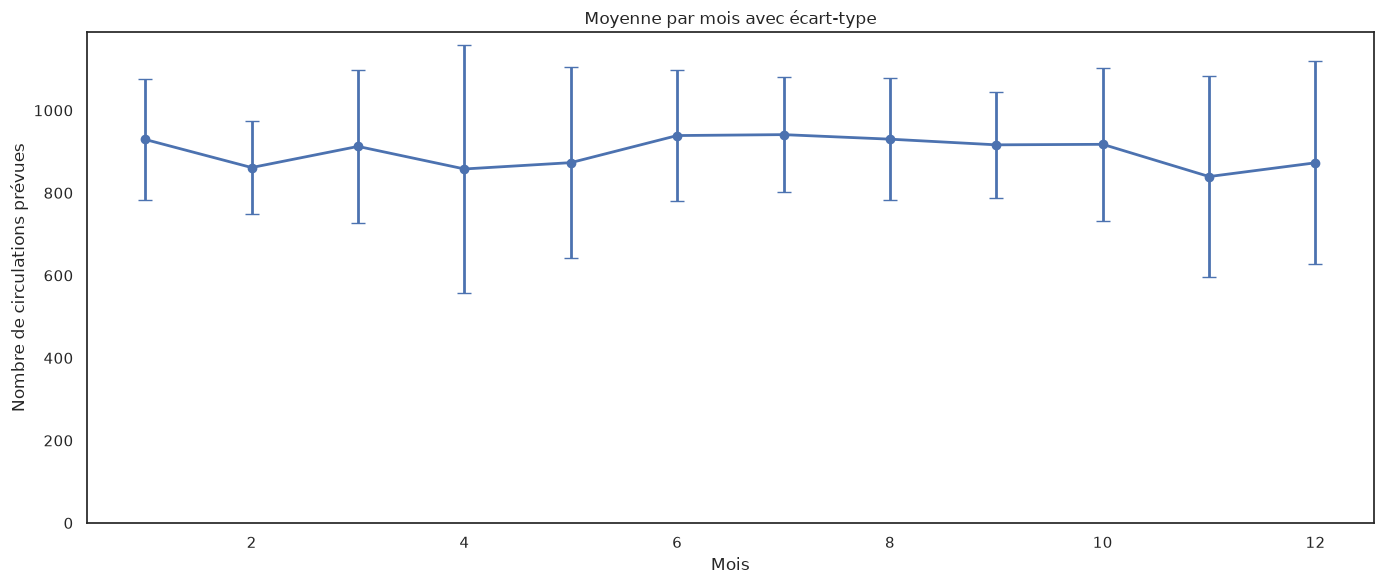

In [ ]:
df_stats = (
    df_analyse.groupby("Mois")[colonne]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(14,6))
plt.errorbar(
    df_stats["Mois"],
    df_stats["mean"],
    yerr=df_stats["std"],
    fmt="-o",
    capsize=5,
    linewidth=2
)
plt.ylim(bottom=0)
plt.title("Nombre moyen de circulations prévues par mois avec écart-type")
plt.xlabel("Mois")
plt.ylabel(colonne)
plt.tight_layout()
plt.show()

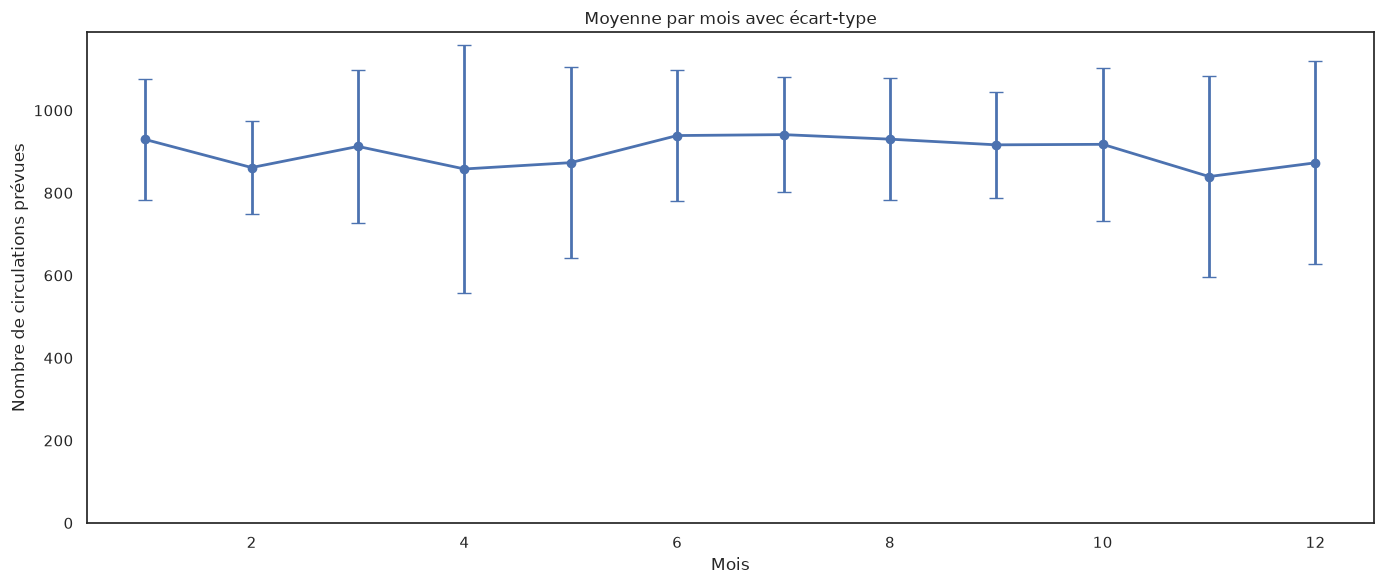

In [ ]:
df_analyse = df_analyse.query("`Gare de départ` == 'BORDEAUX ST JEAN' and `Gare d'arrivée` == 'PARIS MONTPARNASSE'")
df_stats = (
    df_analyse.groupby("Mois")[colonne]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(14,6))
plt.errorbar(
    df_stats["Mois"],
    df_stats["mean"],
    yerr=df_stats["std"],
    fmt="-o",
    capsize=5,
    linewidth=2
)
plt.ylim(bottom=0)
plt.title("Nombre moyen de circulations prévues par mois avec écart-type - BORDEAUX ST JEAN -> PARIS MONTPARNASSE")
plt.xlabel("Mois")
plt.ylabel(colonne)
plt.tight_layout()
plt.show()

Les données de circulations prévues ont l'air d'être correctes. on a cependant un gros écart type (plus élevé que la moyenne) sur les circulations prévues par mois. Donc la prévision de circulation précues semble compromise. 
